In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from tobii_pytracker.analyze.data_loader import DataLoader
from tobii_pytracker.configs.custom_config import CustomConfig

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from tobii_pytracker.analyze.models import (
    HeatmapAnalyzer,
    FocusMapAnalyzer,
    FixationAnalyzer,
    SaccadeAnalyzer,
    EntropyAnalyzer,
    ClusterAnalyzer,
    ConceptAnalyzer,
    ScanpathsAnalyzer,
    VoiceTranscription
)


config = CustomConfig('../configs/config.yaml')
loader = DataLoader(config, root='../')

▶ Global heatmap statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-73.55845,52.570201,596


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,-73.55845,52.570201,596


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,0,0.496672,126.178458,54
1,20260712_201106,1,-136.970846,86.770293,41
2,20260712_201106,2,-119.749876,110.488777,63
3,20260712_201106,3,-56.953125,51.798718,53
4,20260712_201106,4,-42.326600,18.074442,105


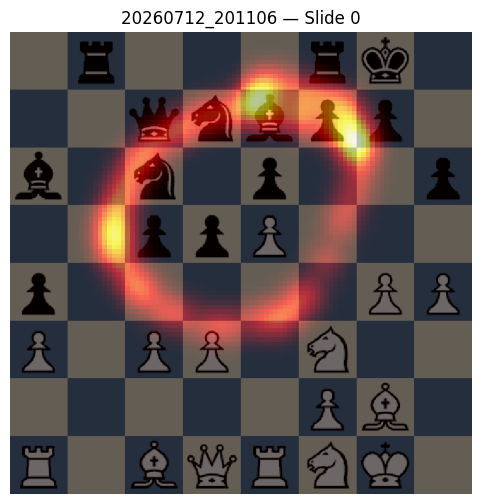

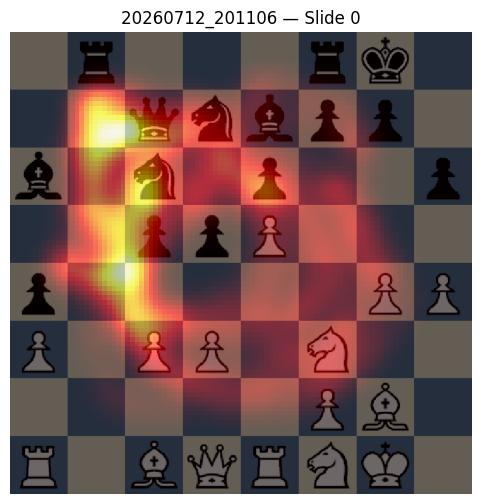

In [12]:
# Assuming you already have the data
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = HeatmapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global heatmap statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# --- Plot heatmap for one image ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']}",
)


▶ Global focus map statistics


,avg_gaze_x,avg_gaze_y,gaze_count
0,-73.55845,52.570201,596


▶ Per-set statistics


,set_name,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,-73.55845,52.570201,596


▶ Per-slide statistics


,set_name,slide_index,avg_gaze_x,avg_gaze_y,gaze_count
0,20260712_201106,0,0.496672,126.178458,54
1,20260712_201106,1,-136.970846,86.770293,41
2,20260712_201106,2,-119.749876,110.488777,63
3,20260712_201106,3,-56.953125,51.798718,53
4,20260712_201106,4,-42.326600,18.074442,105


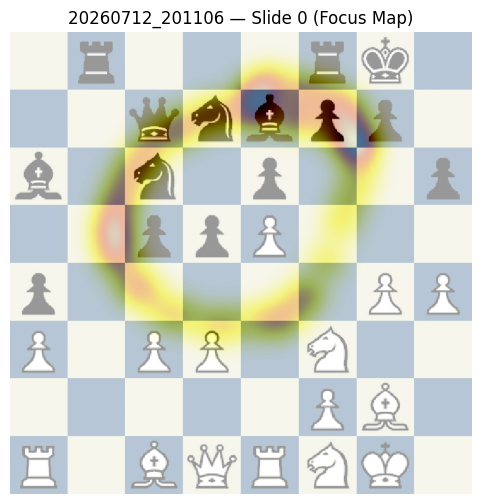

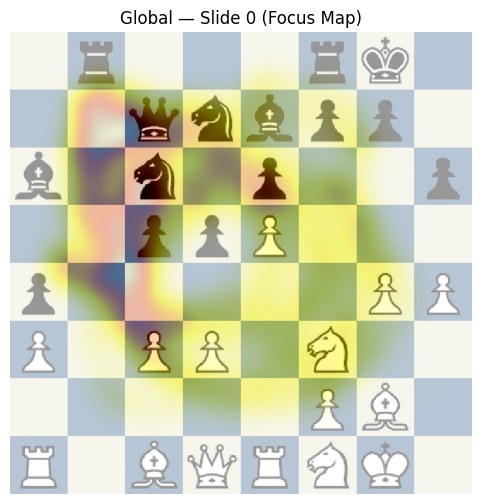

In [13]:
# --- Prepare background data ---
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

analyzer = FocusMapAnalyzer(output_folder=output_dir)

# --- Global ---
print("▶ Global focus map statistics")
global_stats = analyzer.analyze(background_data, per="global")
display(global_stats)

# --- Set-level ---
print("▶ Per-set statistics")
set_stats = analyzer.analyze(background_data, per="set")
display(set_stats.head())

# --- Slide-level ---
print("▶ Per-slide statistics")
slide_stats = analyzer.analyze(background_data, per="slide")
display(slide_stats.head())

# ============================================================
# 🖼 Plot focus map for one example slide
# ============================================================

example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

# --- Focus map for single slide (individual subject) ---
analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"{example_slide['set_name']} — Slide {example_slide['slide_index']} (Focus Map)",
)

# --- Focus map using all gaze data for this slide (across subjects) ---
analyzer.plot_analysis(
    background_data=background_data,
    screenshot_path=screenshot_path,
    title=f"Global — Slide {example_slide['slide_index']} (Focus Map)",
)

▶ Detecting saccades...


,set_name,slide_index,start_time,end_time,duration,x_start,y_start,x_end,y_end,amplitude,peak_velocity,mean_velocity,mean_acceleration
0,20260712_201106,0,24.076338,25.089039,1.033287,180.335938,201.679688,16.097656,260.117188,174.324853,4547.681049,1411.082877,35677.049701
1,20260712_201106,1,30.670398,30.670398,0.020742,-186.292969,208.664062,-186.984375,208.664062,0.691406,33.333099,33.333099,10237.456407
2,20260712_201106,1,30.711734,31.415082,0.724024,-189.949219,207.335938,-245.160156,214.386719,55.659331,4231.421946,1497.438531,33243.295828
3,20260712_201106,2,37.311041,38.370047,1.079624,-166.210938,227.386719,-240.464844,256.140625,79.626815,2428.790229,1218.113843,22052.797135
4,20260712_201106,3,46.628529,47.630307,1.022472,-112.355469,201.062500,-195.468750,24.867188,194.814285,3633.812877,1542.605384,28687.055401


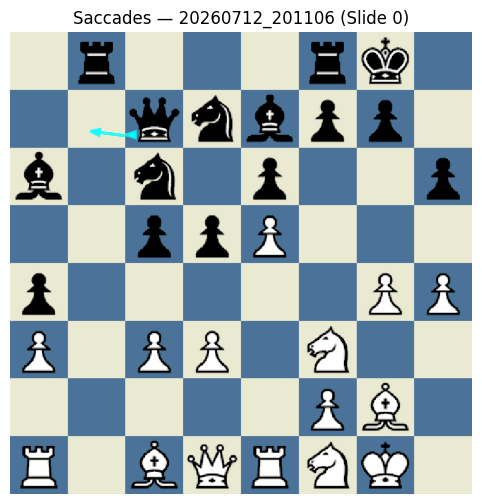

In [14]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

saccade_analyzer = SaccadeAnalyzer(
    output_folder=output_dir,
    method="ivt",               # "ivt" (velocity-based) or "acceleration"
    velocity_threshold=120.0,   # pixels/sec
    acceleration_threshold=6000.0,  # pixels/sec^2
    min_duration=0.015,         # seconds
)

print("▶ Detecting saccades...")
saccades = saccade_analyzer.analyze(background_data)
display(saccades.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

saccade_analyzer.plot_analysis(
    saccades=saccades,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Saccades — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Detecting fixations...


,fix_start,fix_end,duration,x_mean,y_mean,dispersion,set_name,slide_index
0,30.628896,30.753075,0.124179,-196.689732,201.482143,60.027344,20260712_201106,1
1,31.332533,31.435692,0.103159,-240.699870,217.049479,31.878906,20260712_201106,1
2,37.269763,37.393723,0.123959,-185.434152,224.215960,66.914062,20260712_201106,2
3,38.214562,38.328224,0.113662,-213.324777,266.208705,65.773438,20260712_201106,2
4,38.348852,38.514489,0.165637,-241.410156,253.061198,14.339844,20260712_201106,2


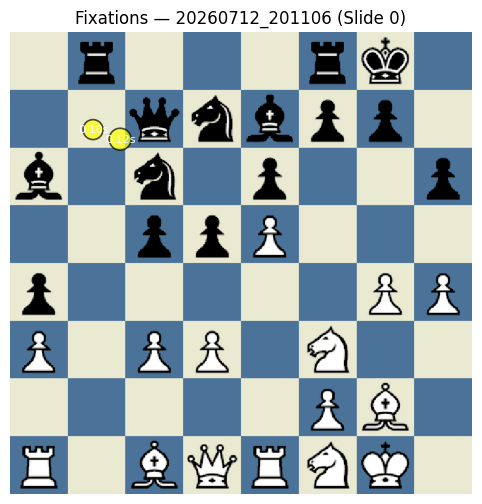

In [15]:
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

fixation_analyzer = FixationAnalyzer(
    output_folder=output_dir,
    method="dispersion",           # or "velocity"
    dispersion_threshold=60.0,     # pixels
    min_duration=0.08,             # seconds
)

print("▶ Detecting fixations...")
fixations = fixation_analyzer.analyze(background_data)
display(fixations.head())

example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

fixation_analyzer.plot_analysis(
    fixations=fixations,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Fixations — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Performing gaze clustering...


,set_name,slide_index,screenshot_file,input_data,classification,user_classification,model_prediction,voice_file,voice_start_timestamp,event_type,...,gaze_x_left,gaze_y_left,gaze_x_right,gaze_y_right,pupil_left,pupil_right,avg_gaze_x,avg_gaze_y,avg_pupil_size,cluster
0,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,194.183594,192.035156,None,None,5,0,194.183594,192.035156,2.5,0
1,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,180.335938,201.679688,None,None,5,0,180.335938,201.679688,2.5,0
2,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,169.066406,209.187500,None,None,5,0,169.066406,209.187500,2.5,0
3,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,140.296875,221.882812,None,None,5,0,140.296875,221.882812,2.5,-1
4,20260712_201106,0,output/20260712_201106/frame_34_delay-1s.gif,datasets/chess/good/frame_34_delay-1s.gif,good,good,None,NaN,NaN,MonocularEyeSampleEventNT,...,104.863281,233.472656,None,None,5,0,104.863281,233.472656,2.5,-1


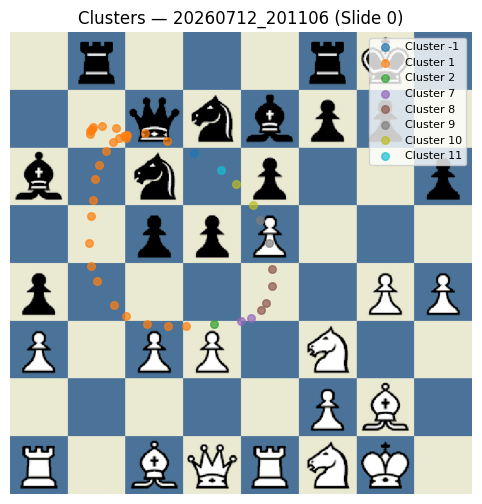

In [16]:
# ==============================================
# 👁️ Cluster Analyzer Demo
# ==============================================
from pathlib import Path
import pandas as pd

background_data= pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

# Instantiate analyzer (DBSCAN by default)
cluster_analyzer = ClusterAnalyzer(
    output_folder=output_dir,
    eps=20,              # pixel distance for clustering
    min_samples=3,        # minimum points per cluster
)

print("▶ Performing gaze clustering...")
clustered_data = cluster_analyzer.analyze(background_data)
display(clustered_data.head())

# --- Visualization for one slide ---
example_slide = background_data.iloc[0]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

cluster_analyzer.plot_analysis(
    background_data=clustered_data,
    screenshot_path=screenshot_path,
    set_name=example_slide["set_name"],
    slide_index=int(example_slide["slide_index"]) + 1,
    title=f"Clusters — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)

▶ Slide-level entropy


,entropy,convex_hull_area,num_points,set_name,slide_index
0,5.754888,113816.371544,54,20260712_201106,0
1,5.308772,75842.237625,41,20260712_201106,1
2,5.743075,118544.655876,63,20260712_201106,2
3,5.727920,141673.909378,53,20260712_201106,3
4,6.426011,149693.160469,105,20260712_201106,4


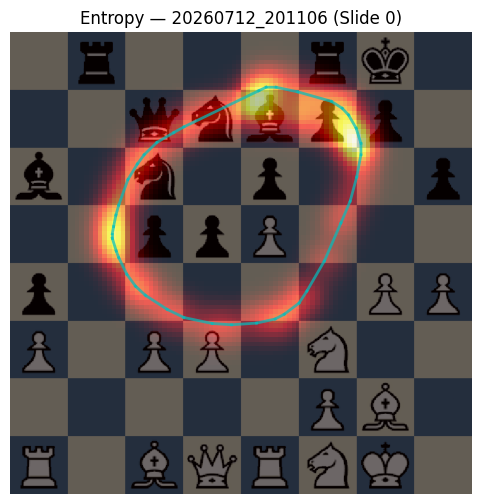

In [17]:
# ==============================================
# 🧠 Entropy Analyzer Demo
# ==============================================
background_data = pd.concat(loader.get_all_data(flatten=True).values(), ignore_index=True)
output_dir = Path("./analysis_outputs")

entropy_analyzer = EntropyAnalyzer(output_folder=output_dir)

print("▶ Slide-level entropy")
entropy_results = entropy_analyzer.analyze(background_data, per="slide", bins=100, use_convex_hull=True)
display(entropy_results.head())

# --- Visualization for one example slide ---
example_slide = background_data.iloc[0]
subset = background_data[
    (background_data["set_name"] == example_slide["set_name"]) &
    (background_data["slide_index"] == example_slide["slide_index"])
]
screenshot_path = Path(loader.root) / example_slide["screenshot_file"]

entropy_analyzer.plot_analysis(
    background_data=subset,
    screenshot_path=screenshot_path,
    title=f"Entropy — {example_slide['set_name']} (Slide {example_slide['slide_index']})",
)
